In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

import time

In [2]:
N = 100 # Number of agents

T = 1_000 # Length of Simulation

Mmax = 100 # Max possible money per agent
theta = 0.01 # Proportional change of prices in market
epsilon = 0.5 # Proportion of randomizing prices for agent
max_tries = 100 # Max number of market attempts

# Define Productivity Coefficients (Direct Labor Coefficients)
l1 = 10.0
l2 = 1.0

# Define the desired consumption rate
c1 = 0.1/2.
c2 = 1.0/2.

# The macro-economic condition must be satisfied
# l1*c1 + l2*c2 <= 1.0
print(l1*c1 + l2*c2)



1.0


In [3]:
# Inititialize Market Simulation
sim = PRE.PriceRatioExperiment(N, l1, l2, c1, c2, Mmax=Mmax, theta=theta, epsilon=epsilon, max_tries=max_tries, initial_money='uniform')

In [4]:
start_ = time.time()
Me_df, Qe_df, ntries_df, p_df, Magent_df = sim.run_experiment(T)
end_ = time.time()

C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:109: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df


In [5]:
lapse = end_ - start_
print(lapse, lapse/N)

107.8455901145935 1.0784559011459351


In [6]:
sim.scda.agent_data.shape

(100, 3, 2)

Text(0, 0.5, 'Market Attempts')

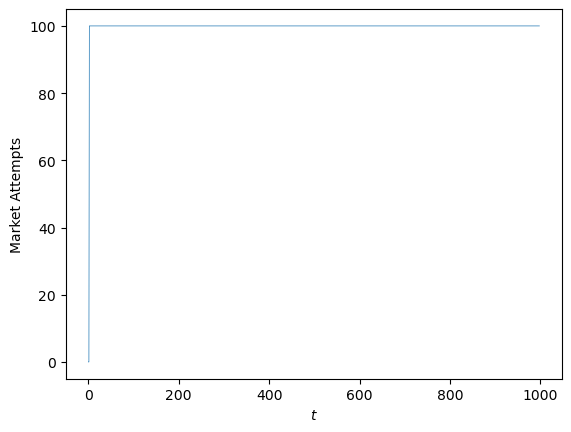

In [7]:
f, ax = plt.subplots()
ax.plot(ntries_df, lw=0.5)
ax.set_xlabel('$t$')
ax.set_ylabel('Market Attempts')

Text(0, 0.5, 'Price')

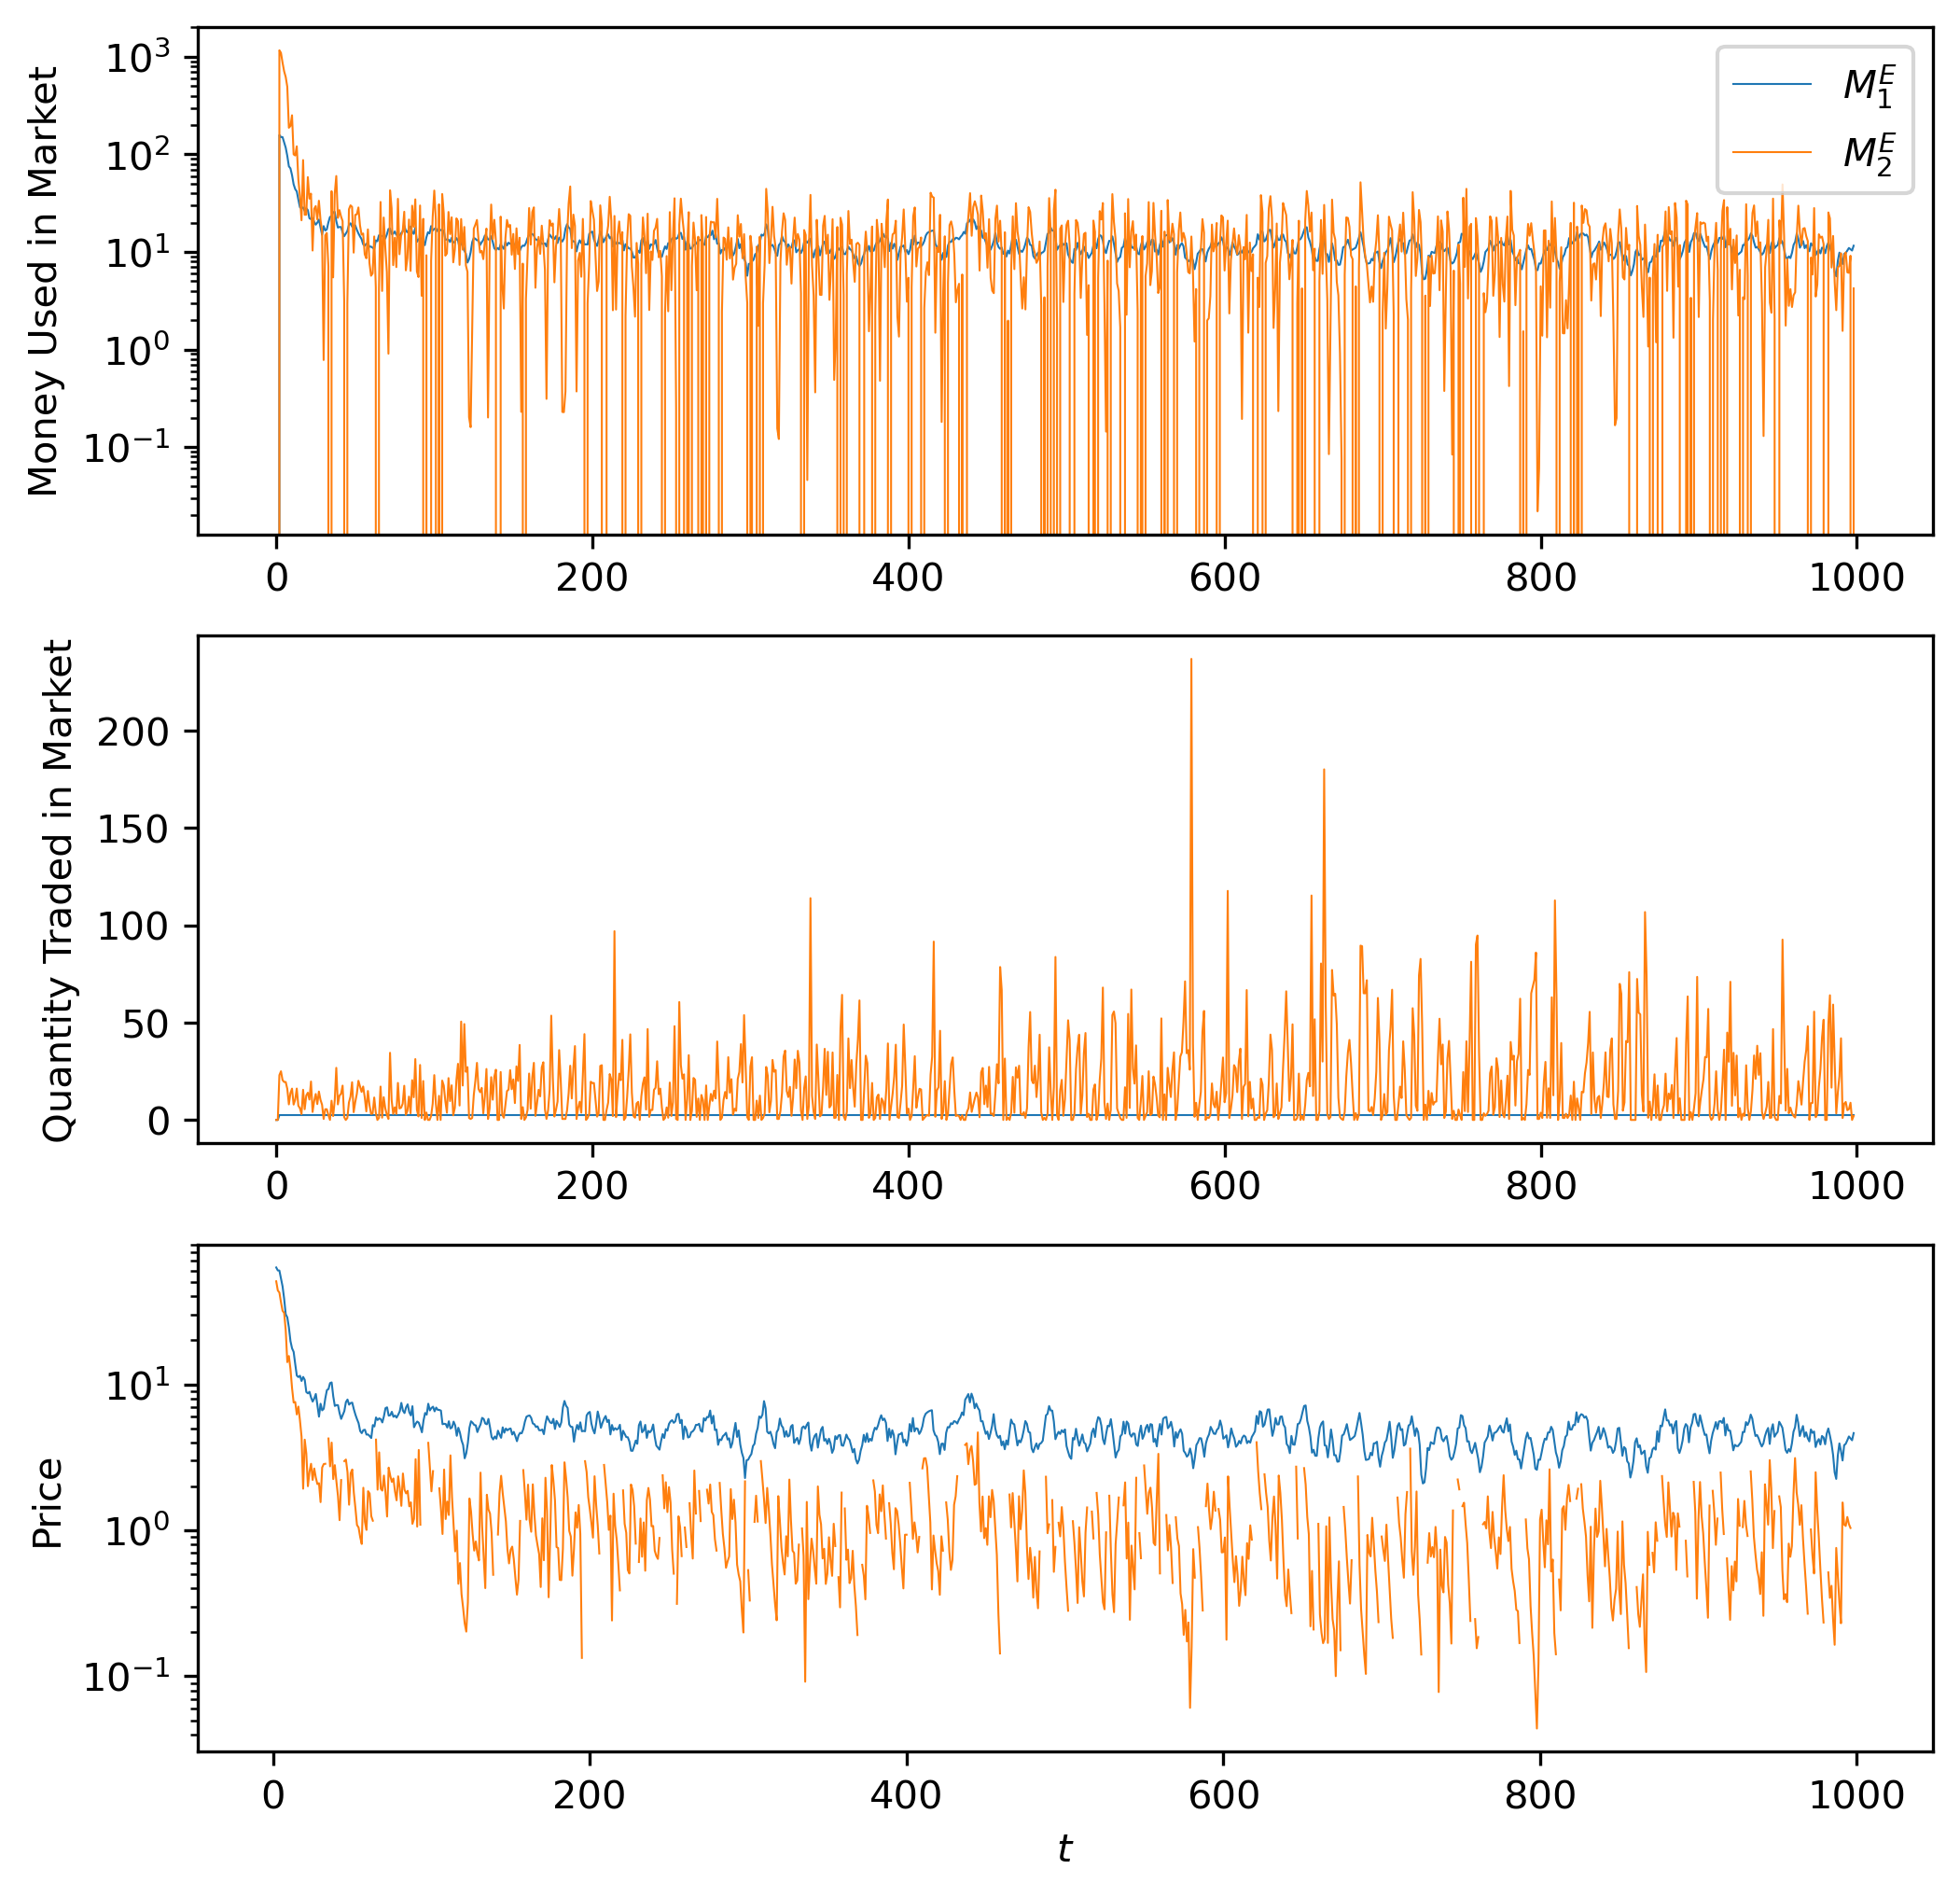

In [8]:
plt.rcParams['figure.dpi'] = 300
f, ax = plt.subplots(3,1, figsize=(8,8))
for i in range(2):
    ax[0].plot(Me_df[:,i], label=f'$M^E_{i+1}$', lw=0.5)
    ax[1].plot(Qe_df[:,i], label=f'%Q^E_{i+1}$', lw=0.5)
ax[2].plot(p_df, label=f'$p_{i+1}$', lw=0.5)
    
    
ax[0].legend()
ax[0].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('$t$')
ax[0].set_ylabel('Money Used in Market')
ax[1].set_ylabel('Quantity Traded in Market')
ax[2].set_ylabel('Price')

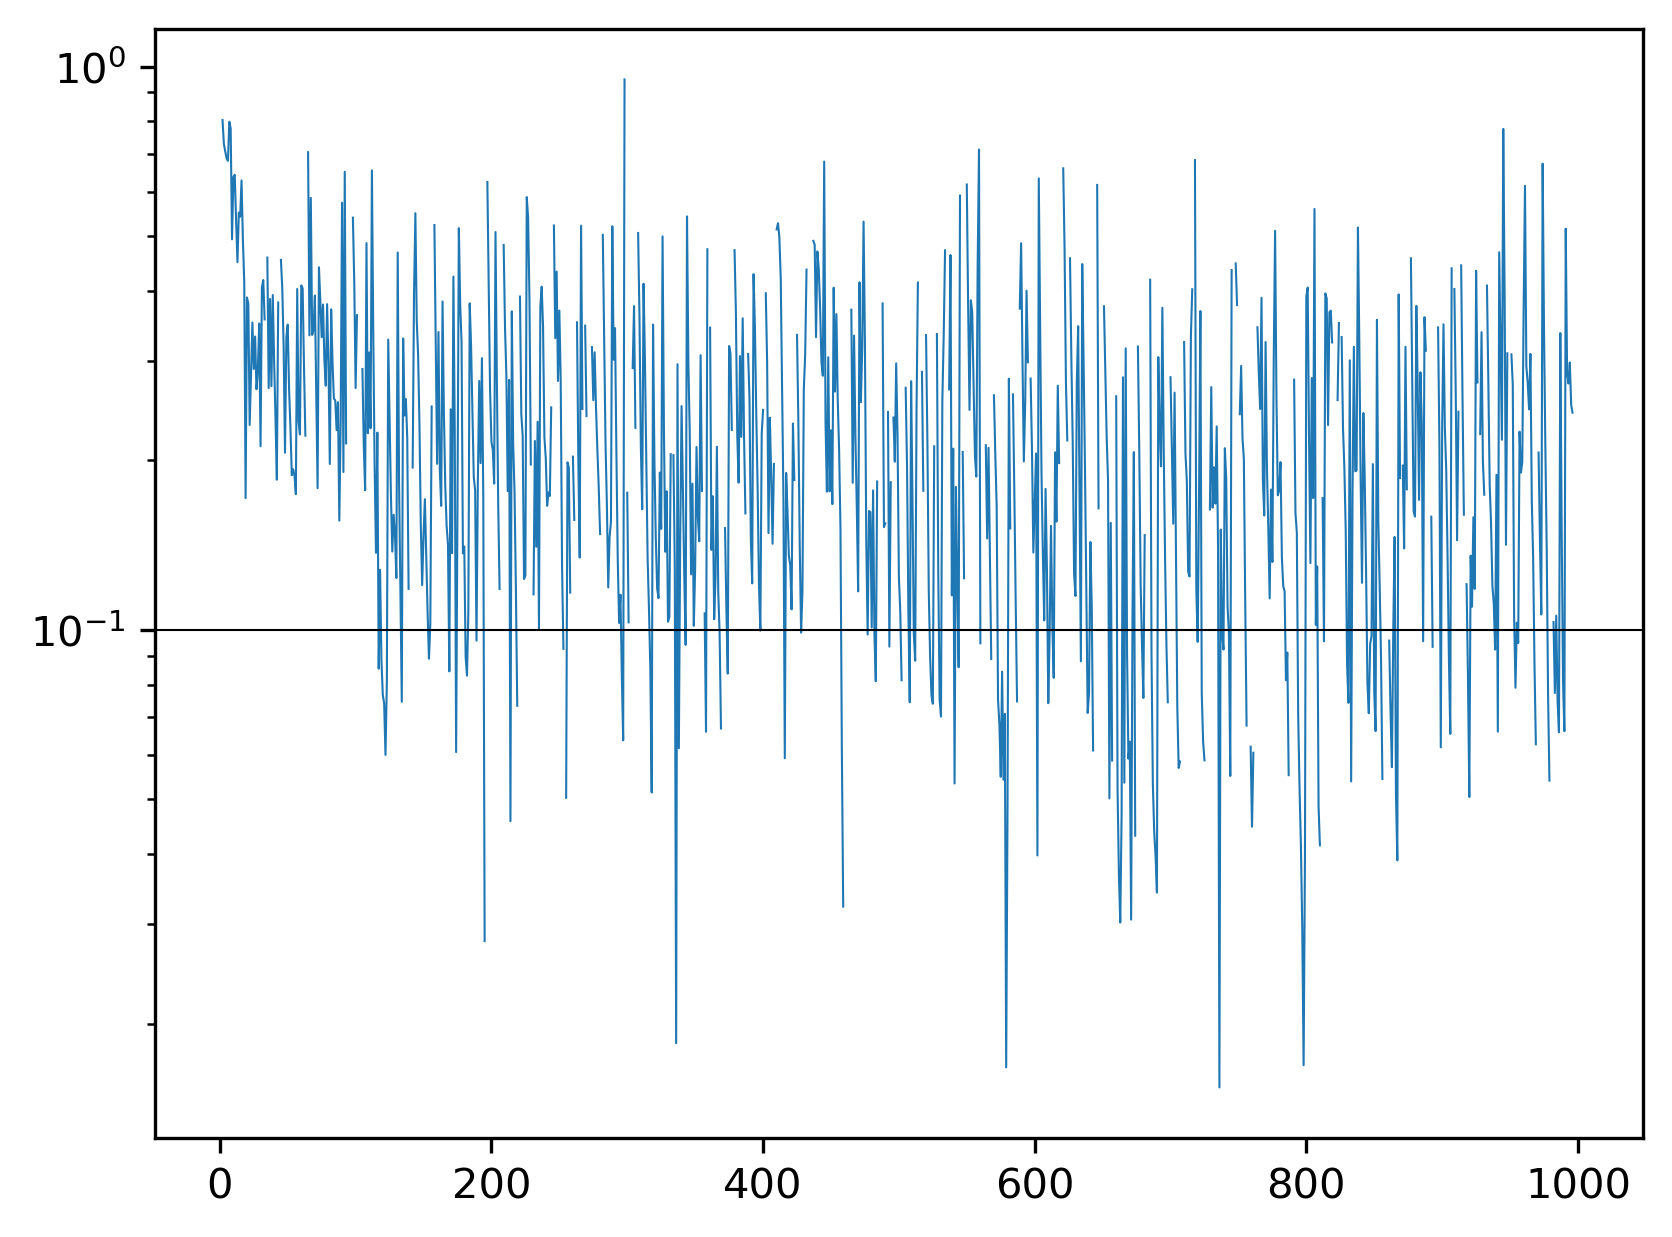

In [9]:
plt.plot(p_df[:,1]/p_df[:,0], label=f'$p_2/p_1$', lw=0.5)
plt.axhline(l2/l1, lw=0.5, c='k')
plt.yscale('log')


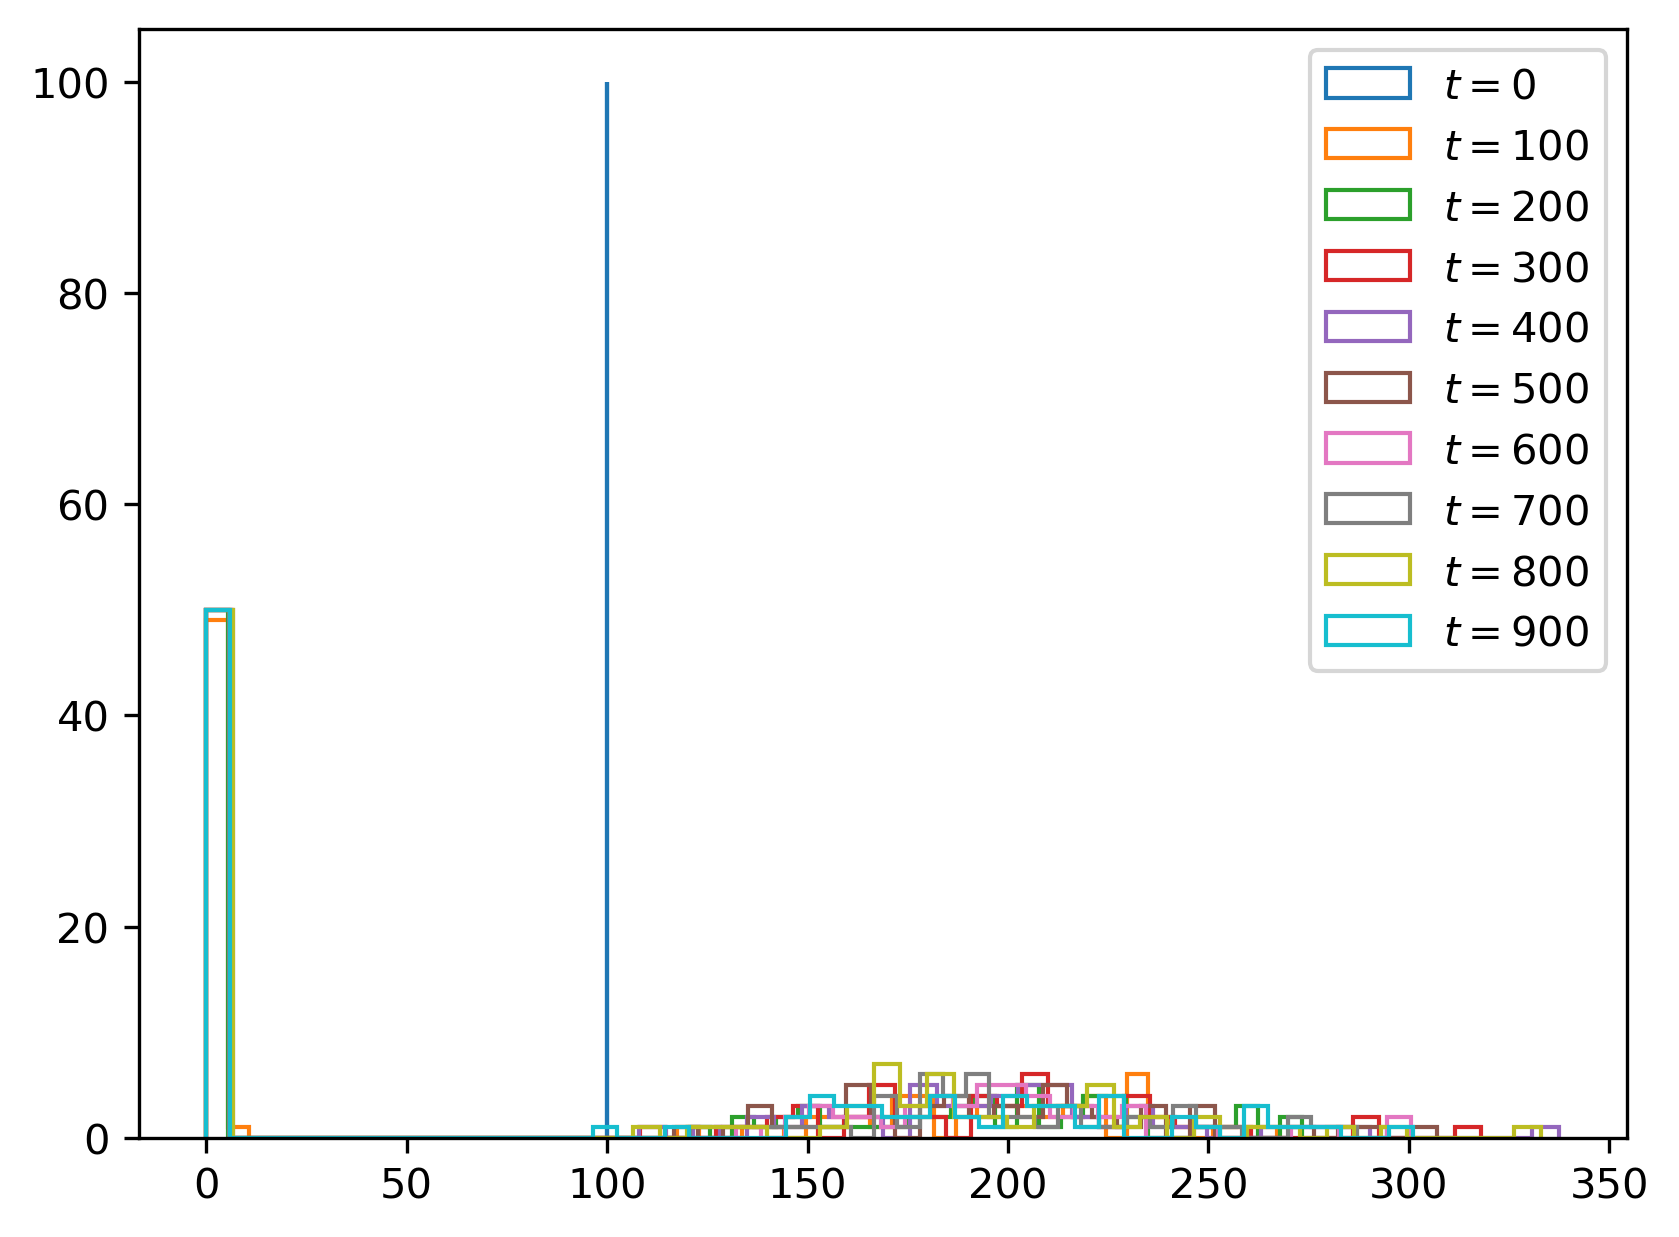

In [10]:
f, ax = plt.subplots()

for t in np.arange(0, T, 100):
    ax.hist(Magent_df[t], histtype='step', bins=50, label=f'$t={t}$')
ax.legend()

In [11]:
#Magent_df[10:].mean(axis=0)

array([  0.8104015 ,   0.70906574,   0.8082806 ,   0.92162079,
         0.8021878 ,   0.79058805,   0.75465505,   0.75914484,
         0.79714214,   0.70054516,   0.81360749,   0.77463359,
         0.73952987,   0.78958541,   0.76177426,   0.77685447,
         0.7471613 ,   0.76095344,   0.78433156,   0.74078813,
         0.83292517,   0.69818116,   0.76165541,   0.71615011,
         0.80620196,   0.83334557,   0.83290983,   0.81083445,
         0.79769237,   0.79919476,   0.78057311,   0.81180269,
         0.73289398,   0.7664704 ,   0.77251426,   0.80731533,
         0.82327046,   0.81317253,   0.82308901,   0.79899855,
         0.80304498,   0.78801958,   0.7899192 ,   0.77675112,
         0.80485418,   0.83007697,   0.761265  ,   0.84280945,
         0.79903089,   0.77131357, 175.8395107 , 195.47523183,
       228.57035494, 191.57768972, 189.40037427, 179.80650079,
       185.86983005, 264.82012648, 179.07773205, 223.24639899,
       204.03378153, 278.57309056, 202.07705446, 196.09

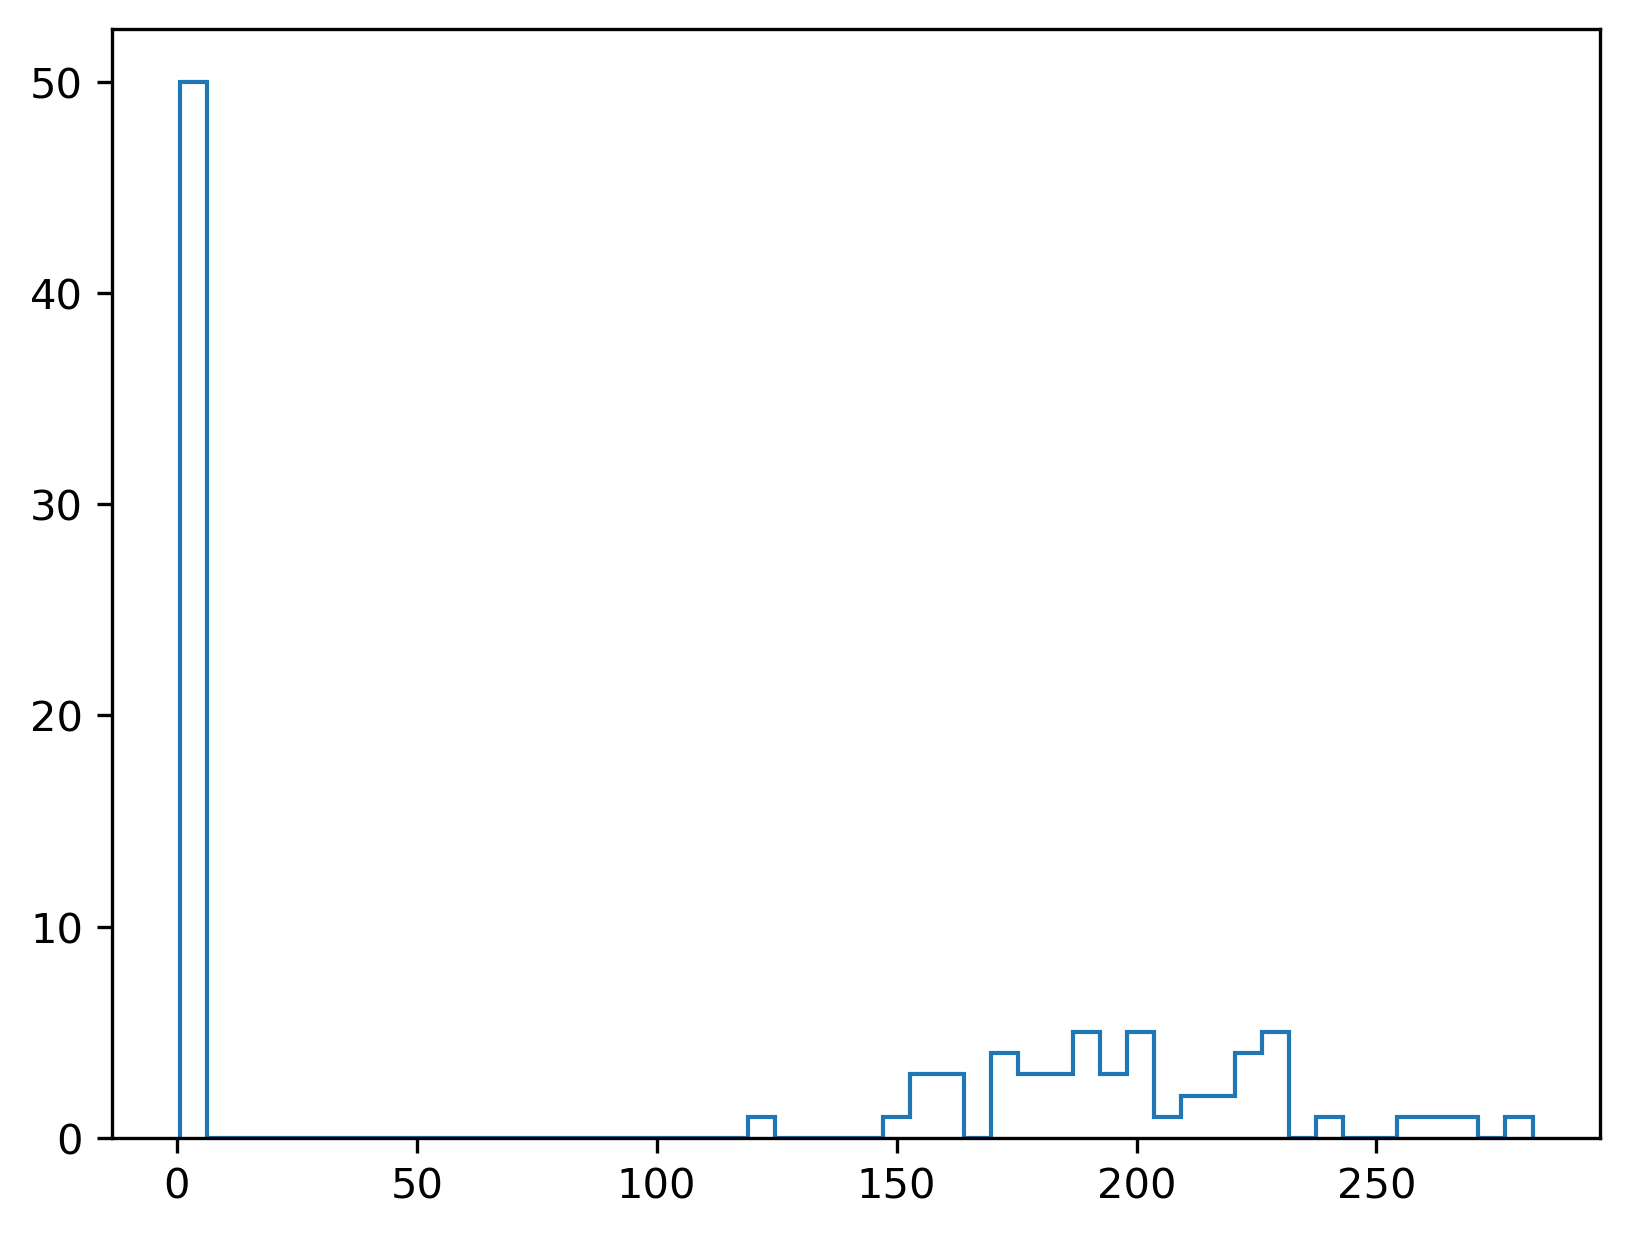

In [12]:
plt.hist(Magent_df[100:].mean(axis=0), histtype='step', bins=50)
plt.show()

In [ ]:
assert False

In [39]:
from scipy.signal import find_peaks
from sklearn.mixture import GaussianMixture

(array([48.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
         1., 18., 25.,  5.]),
 array([-0.21007369, -0.12136908, -0.03266447,  0.05604015,  0.14474476,
         0.23344937,  0.32215398,  0.41085859,  0.4995632 ,  0.58826782,
         0.67697243,  0.76567704,  0.85438165,  0.94308626,  1.03179087,
         1.12049549,  1.2092001 ,  1.29790471,  1.38660932,  1.47531393,
         1.56401854,  1.65272316,  1.74142777,  1.83013238,  1.91883699,
         2.0075416 ,  2.09624621,  2.18495083,  2.27365544,  2.36236005,
         2.45106466]),
 <BarContainer object of 30 artists>)

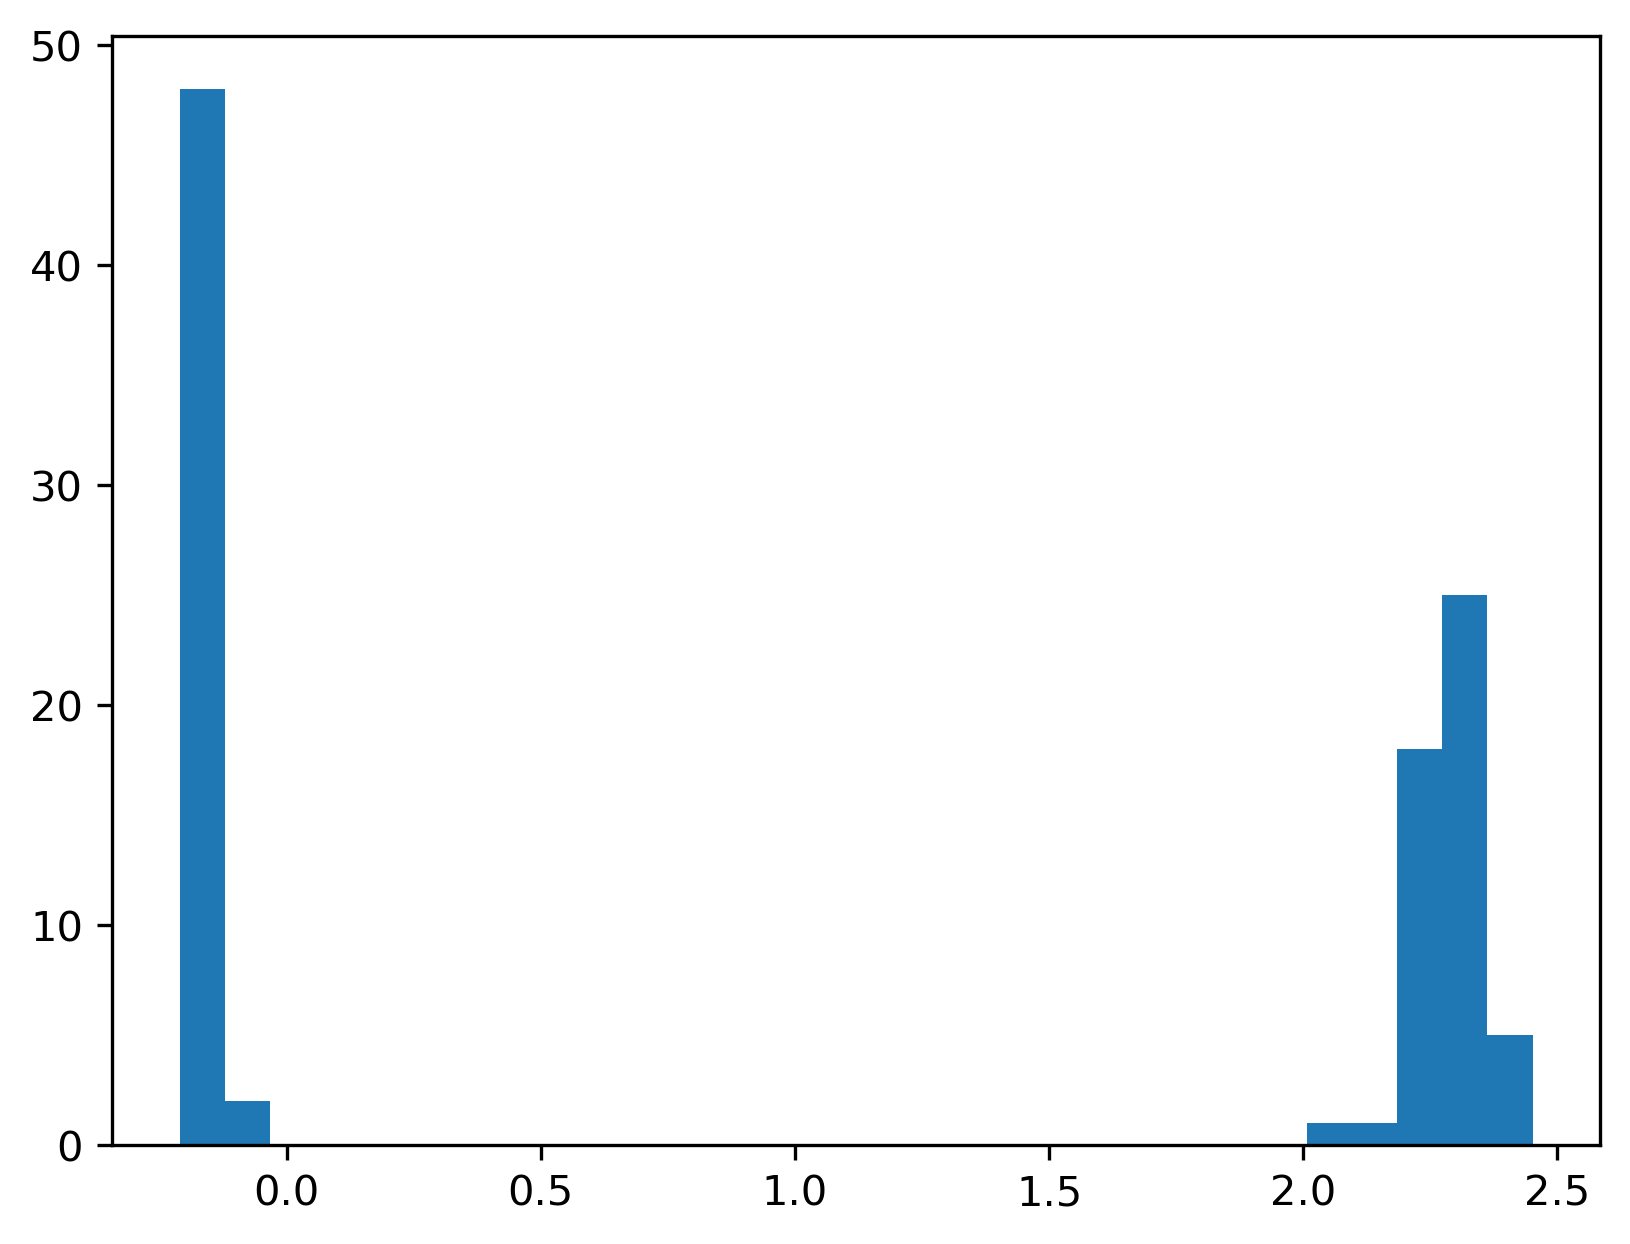

In [59]:
start_time = 100
data = np.log10(Magent_df[start_time:].mean(axis=0))
plt.hist(data, bins=30)

In [60]:
# Finding peaks in the histogram
nbins = 25
hist, bin_edges = np.histogram(data, bins=nbins)
peaks, _ = find_peaks(hist)

peaks, _

(array([23], dtype=int64), {})

In [63]:
gmm = GaussianMixture(n_components=2)
gmm.fit(data.reshape(-1,1))
gmm.means_.flatten()

C:\Users\Alex\anaconda3\envs\pytorchgame3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([196.66000646,   0.69257449])

array([23], dtype=int64)

In [13]:
assert False

AssertionError: 

In [ ]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [ ]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            print(l1, l2)
            print(c1, c2)
            print(pre.N1, pre.N2)
            print(l1*c1 + l2*c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

In [ ]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

In [ ]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

In [ ]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')